In [33]:
# import sys
# !{sys.executable} -m pip install -q scikit-image

In [34]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

from L1.LibLv1 import create_efficientnet_models, load_model_from_weights_and_compile
from L2.LibLv2 import create_autoencoder

In [35]:
def run_pipeline(image_paths, classifier_weights, autoencoder_weights,
                 class_names=['Not Photo', 'Photo'],
                 image_size=(224, 224),
                 gpu_device='/GPU:1'):
    """
    Classifies and enhances a batch of images, grouped by pipeline step.
    """
    print("\n==========================")
    print("📦 Starting Inference Pipeline")
    print("==========================\n")

    if isinstance(image_paths, str):
        image_paths = [image_paths]

    version = extract_efficientnet_version(classifier_weights)

    with tf.device(gpu_device):
        # ------------------------ Load Models ------------------------
        print("🔍 [Model 1: Loading EfficientNet Classifier]")
        classifier = create_efficientnet_models(
            input_shape=(*image_size, 3),
            class_count=len(class_names),
            version=version,
            dropout_rate=0.3,
            fine_tune_at=-1
        )
        classifier = load_model_from_weights_and_compile(classifier, classifier_weights)
        if classifier is None:
            print("❌ Could not load classifier model.")
            return

        print("✨ [Model 2: Loading Autoencoder]")
        autoencoder = create_autoencoder((*image_size, 3))
        try:
            autoencoder.load_weights(autoencoder_weights)
            print("✅ Autoencoder weights loaded.\n")
        except Exception as e:
            print(f"❌ Failed to load autoencoder weights: {e}")
            return

        images_raw = []
        images_array = []
        predictions = []

        # ------------------------ STEP 1: Classification ------------------------
        print("\n============================")
        print("🔍 STEP 1: Classification with Model 1")
        print("============================\n")

        for path in image_paths:
            img_raw = image.load_img(path, target_size=image_size)
            img_array = image.img_to_array(img_raw)
            img_batch = np.expand_dims(preprocess_input(img_array.copy()), axis=0)

            pred = classifier.predict(img_batch)
            class_idx = np.argmax(pred[0])
            class_label = class_names[class_idx]
            confidence = pred[0][class_idx]

            predictions.append((class_label, confidence))
            images_raw.append(img_raw)
            images_array.append(img_array)

            print(f"🖼️ {os.path.basename(path)} → {class_label} ({confidence:.2%})")

        # Display all predictions visually
        for i, (img, (label, conf)) in enumerate(zip(images_raw, predictions)):
            plt.figure(figsize=(4, 4))
            plt.imshow(img)
            plt.title(f"[Model 1] {label} ({conf:.2%})")
            plt.axis("off")
            plt.show()

        # ------------------------ STEP 2: Enhancement ------------------------
        print("\n============================")
        print("✨ STEP 2: Enhancement with Model 2")
        print("============================\n")

        for i, (label, _) in enumerate(predictions):
            if label != 'Photo':
                print(f"🚫 Skipping {os.path.basename(image_paths[i])} (Not Photo)")
                continue

            img_array = images_array[i]
            img_batch = np.expand_dims(img_array / 255.0, axis=0)
            enhanced = autoencoder.predict(img_batch)

            # Display before and after
            plt.figure(figsize=(10, 4))

            plt.subplot(1, 2, 1)
            plt.imshow(img_array.astype("uint8"))
            plt.title("Model 2 Input (Original)")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(enhanced[0])
            plt.title("Model 2 Output (Enhanced)")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

        # ------------------------ STEP 3: Reserved ------------------------
        print("\n============================")
        print("🧪 STEP 3: Reserved for Future Use")
        print("============================\n")


In [36]:
image_list = [
    r"L1\\testResult\\WhatsApp Image 2025-04-08 à 10.02.35_57384aa3.jpg",
    r"L1\\testResult\\lorenzo.jpg",
    r"L1\\testResult\\WhatsApp Image 2025-04-08 à 10.02.35_b655e5ba.jpg"
]


📦 Starting Inference Pipeline

🔍 [Model 1: Loading EfficientNet Classifier]
Fine-tuning activé à partir de la couche -1.
Poids chargés avec succès depuis L1\models\EfficientNetB1_Bin_best_weights.h5
Modèle compilé avec succès.
✨ [Model 2: Loading Autoencoder]
✅ Autoencoder weights loaded.


🔍 STEP 1: Classification with Model 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
🖼️ WhatsApp Image 2025-04-08 à 10.02.35_57384aa3.jpg → Photo (99.96%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
🖼️ lorenzo.jpg → Not Photo (100.00%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
🖼️ WhatsApp Image 2025-04-08 à 10.02.35_b655e5ba.jpg → Not Photo (99.96%)


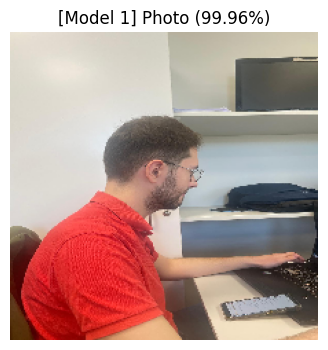

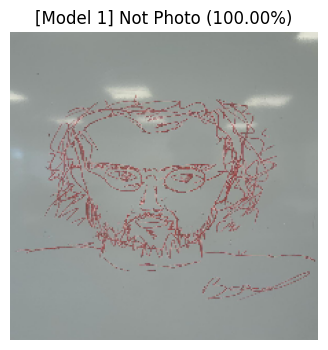

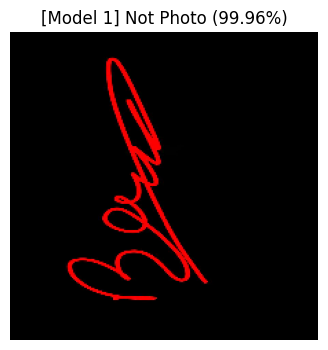


✨ STEP 2: Enhancement with Model 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


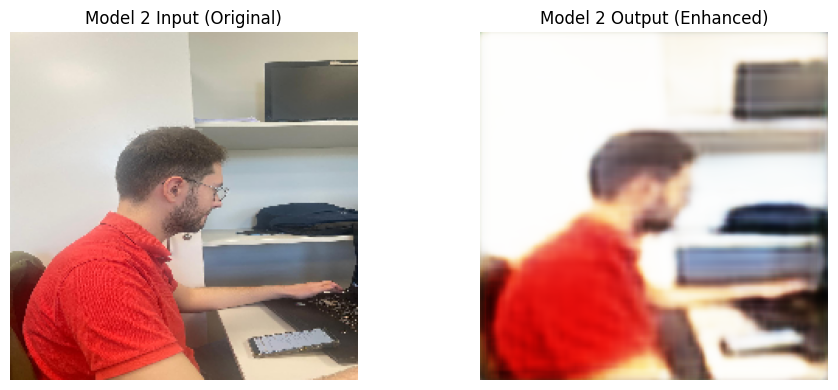

🚫 Skipping lorenzo.jpg (Not Photo)
🚫 Skipping WhatsApp Image 2025-04-08 à 10.02.35_b655e5ba.jpg (Not Photo)

🧪 STEP 3: Reserved for Future Use



In [37]:
run_pipeline(
    image_paths=image_list,
    classifier_weights=r"L1\models\EfficientNetB1_Bin_best_weights.h5",
    autoencoder_weights=r"L2\autoencoder_weights.h5",
    class_names=["Not Photo", "Photo"],
    image_size=(224, 224),
    gpu_device='/GPU:1'  # change to '/GPU:0' if you're using only one GPU
)
